# Customer Data for Validation

* Part 1 creates the hourly observation file, from a combination of the raw customer data and the customer analysis file.
* Part 2 explores battery characteristics
* Part 3 examines electricity consumption variability

In [2]:
import pandas as pd
import numpy as np
import glob
import re
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import shutil

# Part 1 - Generate event-hourly observation file

In [3]:
def detect_battery_ids(columns):
    """Find which battery slots (1, 2, 3...) exist in this customer's raw file,
    based on soc_<n> columns."""
    ids = sorted({
        int(m.group(1)) for c in columns
        if (m := re.fullmatch(r'soc_(\d+)', c))
    })
    return ids

def load_customer_raw(customer_num):
    path_matches = glob.glob(f'customer_data_export/customer_{customer_num}*.csv')
    if not path_matches:
        return None
    df = pd.read_csv(path_matches[0], parse_dates=['timestamp'])
    return df

In [4]:
# ---- Load window assignments (time-of-day, constant per customer across the 3 event days) ----
analysis_df = pd.read_csv('customer_analysis.csv')

'''
#2 no load (away)
#12 missing data
#14 3 batteries w/ strange window behavior
#37 missing data
'''
EXCLUDE_CUSTOMERS = [2, 11, 12, 14, 37, 52, 56]

# per-(customer, battery) exclusions -- for cases where only specific battery
# slots on an otherwise-fine household need to be dropped, e.g. bad sensor
'''
#7 batteries 2, 3 - not decipherable
'''
EXCLUDE_CUSTOMER_BATTERIES = {
    (7, 2),
    (7, 3),
    (41,3),
    (16,),
    (39,1)
}

BATTERY_MODEL = 'Elite 200V2'

records = []

for customer_num in analysis_df['customer'].unique():
    if customer_num in EXCLUDE_CUSTOMERS:
        continue

    raw_df = load_customer_raw(customer_num)
    if raw_df is None:
        print(f"WARNING: no raw file found for customer {customer_num}, skipping")
        continue

    battery_ids = detect_battery_ids(raw_df.columns)
    if not battery_ids:
        print(f"WARNING: no battery columns detected for customer {customer_num}")
        continue

    win_row = analysis_df[analysis_df['customer'] == customer_num]
    window_start = win_row['window_start'].iloc[0]
    window_end = win_row['window_end'].iloc[0]

    raw_df = raw_df.set_index('timestamp').sort_index()
    event_dates = sorted(raw_df.index.normalize().unique())

    for b in battery_ids:
        if (customer_num, b) in EXCLUDE_CUSTOMER_BATTERIES:
            continue

        soc_col = f'soc_{b}'
        grid_col = f'grid_power_kwh_{b}'
        load_col = f'load_power_kwh_{b}'
        disch_col = f'battery_discharge_kwh_{b}'

        needed = [soc_col, grid_col, load_col, disch_col]
        if not all(c in raw_df.columns for c in needed):
            continue

        battery_df = raw_df[needed].copy()

        # resample 15-min -> hourly: energy columns sum (kWh/hr == avg kW that hour),
        # SoC takes the value at the start of each hour.
        # min_count=4 forces an hour with any missing 15-min reading to become NaN
        # rather than silently summing a partial hour.
        hourly_energy = battery_df[[grid_col, load_col, disch_col]].resample('1h').sum(min_count=4)
        hourly_soc = battery_df[[soc_col]].resample('1h').first()
        hourly = hourly_energy.join(hourly_soc)

        for event_idx, day in enumerate(event_dates, start=1):
            day_start = pd.Timestamp.combine(day.date(), pd.to_datetime(window_start).time())
            day_end = pd.Timestamp.combine(day.date(), pd.to_datetime(window_end).time())
            day_start = day_start.tz_localize(hourly.index.tz)
            day_end = day_end.tz_localize(hourly.index.tz)

            # half-open interval [day_start, day_end) so a 4-hour window (e.g. 16:00-20:00)
            # returns exactly 4 hourly rows (16, 17, 18, 19), not 5 -- the row labeled
            # 20:00 represents 20:00-21:00, which is outside the window
            window_df = hourly.loc[(hourly.index >= day_start) & (hourly.index < day_end)]
            if window_df.empty:
                continue

            # added to capture final SoC state
            if day_end in hourly.index:
                soc_pct_window_end = hourly.loc[day_end, soc_col]
            else:
                soc_pct_window_end = np.nan

            for ts, row in window_df.iterrows():
                # discharge = load - grid, exactly, by construction of the raw data.
                # Signed: negative means the battery was charging during this hour,
                # not providing flexibility -- kept as-is rather than clipped to zero.
                observed_flex_kW = row[disch_col]

                records.append({
                    'customer': customer_num,
                    'battery_id': b,
                    'battery_model': BATTERY_MODEL,
                    'event': event_idx,
                    'event_date': day.date(),
                    'timestamp': ts,
                    'hour_of_day': ts.hour,
                    'soc_pct': row[soc_col],
                    'soc_pct_window_end': soc_pct_window_end,
                    'observed_flex_kW': observed_flex_kW,
                    'observed_load_kW': row[load_col],
                    'observed_grid_kW': row[grid_col],
                    'observed_batterydischarge_kW': row[disch_col],
                    'was_charging_in_window': observed_flex_kW < 0,
                })

hourly_validation_df = pd.DataFrame(records)
print(f"Built {len(hourly_validation_df)} hourly observations from "
      f"{hourly_validation_df['customer'].nunique()} households.")
hourly_validation_df.head(10)

Built 924 hourly observations from 53 households.


,customer,battery_id,battery_model,event,event_date,timestamp,hour_of_day,soc_pct,soc_pct_window_end,observed_flex_kW,observed_load_kW,observed_grid_kW,observed_batterydischarge_kW,was_charging_in_window
0,1,1,Elite 200V2,1,2025-06-23,2025-06-23 16:00:00-04:00,16,97.066667,52.533333,0.174750,0.174750,0.000000,0.174750,False
1,1,1,Elite 200V2,1,2025-06-23,2025-06-23 17:00:00-04:00,17,86.866667,52.533333,0.459417,0.459417,0.000000,0.459417,False
2,1,1,Elite 200V2,1,2025-06-23,2025-06-23 18:00:00-04:00,18,63.066667,52.533333,0.095917,0.095917,0.000000,0.095917,False
3,1,1,Elite 200V2,1,2025-06-23,2025-06-23 19:00:00-04:00,19,59.000000,52.533333,0.117950,0.117950,0.000000,0.117950,False
4,1,1,Elite 200V2,2,2025-06-24,2025-06-24 16:00:00-04:00,16,100.000000,62.800000,0.070967,0.133433,0.062467,0.070967,False
5,1,1,Elite 200V2,2,2025-06-24,2025-06-24 17:00:00-04:00,17,95.466667,62.800000,0.181517,0.181517,0.000000,0.181517,False
6,1,1,Elite 200V2,2,2025-06-24,2025-06-24 18:00:00-04:00,18,84.400000,62.800000,0.194083,0.194083,0.000000,0.194083,False
7,1,1,Elite 200V2,2,2025-06-24,2025-06-24 19:00:00-04:00,19,73.266667,62.800000,0.167633,0.167633,0.000000,0.167633,False
8,1,1,Elite 200V2,3,2025-06-25,2025-06-25 16:00:00-04:00,16,98.666667,57.133333,0.175650,0.175650,0.000000,0.175650,False
9,1,1,Elite 200V2,3,2025-06-25,2025-06-25 17:00:00-04:00,17,87.800000,57.133333,0.210683,0.210683,0.000000,0.210683,False


In [5]:
hourly_validation_df[hourly_validation_df['customer']==7]

,customer,battery_id,battery_model,event,event_date,timestamp,hour_of_day,soc_pct,soc_pct_window_end,observed_flex_kW,observed_load_kW,observed_grid_kW,observed_batterydischarge_kW,was_charging_in_window
72,7,1,Elite 200V2,1,2025-06-23,2025-06-23 14:00:00-04:00,14,100.000000,5.0,0.000000,0.000000,0.000000,0.000000,False
73,7,1,Elite 200V2,1,2025-06-23,2025-06-23 15:00:00-04:00,15,100.000000,5.0,0.000000,0.000000,0.000000,0.000000,False
74,7,1,Elite 200V2,1,2025-06-23,2025-06-23 16:00:00-04:00,16,99.333333,5.0,0.700250,0.700250,0.000000,0.700250,False
75,7,1,Elite 200V2,1,2025-06-23,2025-06-23 17:00:00-04:00,17,56.266667,5.0,1.148167,1.148167,0.000000,1.148167,False
76,7,1,Elite 200V2,2,2025-06-24,2025-06-24 14:00:00-04:00,14,96.000000,4.2,-0.129550,1.212833,1.342383,-0.129550,True
77,7,1,Elite 200V2,2,2025-06-24,2025-06-24 15:00:00-04:00,15,96.200000,4.2,0.052217,1.358717,1.306500,0.052217,False
78,7,1,Elite 200V2,2,2025-06-24,2025-06-24 16:00:00-04:00,16,92.733333,4.2,0.589700,1.190017,0.600317,0.589700,False
79,7,1,Elite 200V2,2,2025-06-24,2025-06-24 17:00:00-04:00,17,51.200000,4.2,1.130650,1.458433,0.327783,1.130650,False
80,7,1,Elite 200V2,3,2025-06-25,2025-06-25 14:00:00-04:00,14,100.000000,5.0,-0.000300,1.400817,1.401117,-0.000300,True
81,7,1,Elite 200V2,3,2025-06-25,2025-06-25 15:00:00-04:00,15,100.000000,5.0,0.050150,1.408950,1.358800,0.050150,False


In [6]:
# charging_summary = (hourly_validation_df
#     .groupby('customer')
#     .apply(lambda g: pd.Series({
#         'total_charge_kWh': -g.loc[g['observed_flex_kW'] < 0, 'observed_flex_kW'].sum(),  # positive number
#         'total_discharge_kWh': g.loc[g['observed_flex_kW'] > 0, 'observed_flex_kW'].sum(),
#         'net_flex_kWh': g['observed_flex_kW'].sum(),
#         'n_hours': len(g),
#     }))
# )

# # express charging as a share of total energy movement in the window (charge + discharge),
# # so it's comparable across households regardless of battery size or how "active" the window was
# charging_summary['pct_energy_charging'] = (
#     100 * charging_summary['total_charge_kWh']
#     / (charging_summary['total_charge_kWh'] + charging_summary['total_discharge_kWh']).replace(0, np.nan)
# )

# charging_summary.sort_values('total_charge_kWh', ascending=False)

In [7]:
# # commented out so the file is smaller, but is a useful viz
# def plot_customer_event_windows(customer_num):
#     """Plot SoC, discharge, load, and grid together (one plot per battery),
#     resampled to HOURLY (matching hourly_validation_df), across all event
#     days, with the currently-assigned window shaded."""
#     raw_df = load_customer_raw(customer_num)
#     if raw_df is None:
#         print(f"No raw file for customer {customer_num}")
#         return

#     # Drop tz info now, keeping local wall-clock time, so matplotlib
#     # can't silently relabel ticks in UTC while shading stays in local time.
#     raw_df = raw_df.set_index('timestamp').sort_index()
#     raw_df.index = raw_df.index.tz_localize(None)

#     battery_ids = sorted({
#         int(m.group(1)) for c in raw_df.columns
#         if (m := re.fullmatch(r'soc_(\d+)', c))
#     })
#     if not battery_ids:
#         print(f"No battery columns detected for customer {customer_num}")
#         return

#     analysis_df_local = pd.read_csv('customer_analysis.csv')
#     win_row = analysis_df_local[analysis_df_local['customer'] == customer_num]
#     window_start = win_row['window_start'].iloc[0]
#     window_end = win_row['window_end'].iloc[0]

#     for battery_id in battery_ids:
#         soc_col = f'soc_{battery_id}'
#         disch_col = f'battery_discharge_kwh_{battery_id}'
#         load_col = f'load_power_kwh_{battery_id}'
#         grid_col = f'grid_power_kwh_{battery_id}'

#         needed = [soc_col, disch_col, load_col, grid_col]
#         if not all(c in raw_df.columns for c in needed):
#             print(f"Customer {customer_num}, battery {battery_id}: missing columns, skipping")
#             continue

#         hourly_energy = raw_df[[disch_col, load_col, grid_col]].resample('1h').sum(min_count=4)
#         hourly_soc = raw_df[[soc_col]].resample('1h').first()
#         hourly = hourly_energy.join(hourly_soc)

#         fig, ax1 = plt.subplots(figsize=(16, 6))
#         ax2 = ax1.twinx()

#         ax1.plot(hourly.index, hourly[load_col], label='load (kWh/hr)',
#                  color='tab:green', linewidth=1.5, marker='o', markersize=3)
#         ax1.plot(hourly.index, hourly[grid_col], label='grid (kWh/hr)',
#                  color='tab:red', linewidth=1.5, marker='o', markersize=3)
#         ax1.plot(hourly.index, hourly[disch_col], label='discharge (kWh/hr, signed)',
#                  color='tab:blue', linewidth=1.5, marker='o', markersize=3)
#         ax1.axhline(0, color='gray', linewidth=0.8, linestyle=':')

#         ax2.plot(hourly.index, hourly[soc_col], label='SoC (%)',
#                  color='black', linewidth=1.5, linestyle='--', marker='o', markersize=3)

#         ax1.set_ylabel('Energy (kWh / hr)')
#         ax2.set_ylabel('SoC (%)')
#         ax1.set_xlabel('Timestamp (local)')
#         ax1.set_title(f'Customer {customer_num}, battery {battery_id} — '
#                        f'current window: {window_start}\u2013{window_end} (hourly)')

#         # shade the currently-assigned window on every event day — naive timestamps,
#         # matching hourly.index exactly, so no tz conversion can happen at plot time
#         for day in sorted(hourly.index.normalize().unique()):
#             day_start = pd.Timestamp.combine(day.date(), pd.to_datetime(window_start).time())
#             day_end = pd.Timestamp.combine(day.date(), pd.to_datetime(window_end).time())
#             ax1.axvspan(day_start, day_end, color='gold', alpha=0.25, label='_nolegend_')

#         # x-ticks every 2 hours
#         ax1.xaxis.set_major_locator(mdates.HourLocator(interval=2))
#         ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))

#         lines1, labels1 = ax1.get_legend_handles_labels()
#         lines2, labels2 = ax2.get_legend_handles_labels()
#         ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

#         fig.autofmt_xdate(rotation=45)
#         plt.tight_layout()
#         plt.show()

# # Households with real energy drawn INTO the battery (charging) during the event window,
# # worst offenders first
# customers_with_charging = (
#     charging_summary[charging_summary['total_charge_kWh'] > 0]
#     .sort_values('total_charge_kWh', ascending=False)
#     .index.tolist()
# )

# print(f"{len(customers_with_charging)} households charged during their event window, worst first:")
# print(customers_with_charging)

# for c in customers_with_charging:
#     plot_customer_event_windows(c)

In [8]:
def update_customer_window(customer_num, new_window_start, new_window_end, csv_path='customer_analysis.csv'):
    """
    Updates window_start/window_end for one customer in customer_analysis.csv.
    Saves a timestamped backup of the full file before overwriting, so the
    change is reversible.
    """
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    backup_path = csv_path.replace('.csv', f'_backup_{timestamp}.csv')
    shutil.copy(csv_path, backup_path)
    print(f"Backup saved: {backup_path}")

    df = pd.read_csv(csv_path)
    if customer_num not in df['customer'].values:
        raise ValueError(f"Customer {customer_num} not found in {csv_path}")

    old_start = df.loc[df['customer'] == customer_num, 'window_start'].iloc[0]
    old_end = df.loc[df['customer'] == customer_num, 'window_end'].iloc[0]

    df.loc[df['customer'] == customer_num, 'window_start'] = new_window_start
    df.loc[df['customer'] == customer_num, 'window_end'] = new_window_end
    df.to_csv(csv_path, index=False)

    print(f"Customer {customer_num}: window changed from "
          f"{old_start}\u2013{old_end} to {new_window_start}\u2013{new_window_end}")
    print(f"Saved: {csv_path}")

# Example — update after reviewing the plots above:
# update_customer_window(29, '15:00', '19:00')

In [9]:
#update_customer_window(44,'14:00','18:00')

In [10]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
out_path = f'validation_hourly_observed_{timestamp}.csv'

hourly_validation_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Rows: {len(hourly_validation_df)}, households: {hourly_validation_df['customer'].nunique()}")

Saved: validation_hourly_observed_20260731_154219.csv
Rows: 924, households: 53


# Part 2: Battery Stats

* Battery DoD during events
* Self-consumption
* Charge rates (not really useful)
* Round-trip efficiency

### DoD - event windows only

In [11]:
dod_summary = (hourly_validation_df
    .groupby(['customer', 'battery_id', 'event'])
    .agg(soc_start=('soc_pct', 'first'),
         soc_min=('soc_pct', 'min'),
         soc_end=('soc_pct', 'last'))
)
dod_summary['capacity used pct'] = dod_summary['soc_start'] - dod_summary['soc_min']
dod_summary.sort_values('capacity used pct', ascending=False)

soc_start     soc_min     soc_end  \
customer battery_id event                                       
3        2          1      100.000000    5.000000    5.000000   
8        1          1      100.000000    5.000000    5.000000   
                    2      100.000000    5.000000    5.000000   
15       1          2      100.000000    5.000000    5.000000   
27       2          2      100.000000    5.000000    5.000000   
...                               ...         ...         ...   
54       2          3      100.000000   99.000000   99.000000   
59       2          2      100.000000   99.000000   99.000000   
16       1          1      100.000000   99.066667   99.066667   
31       1          1       99.733333   99.000000   99.000000   
35       1          1      100.000000  100.000000  100.000000   

                           capacity used pct  
customer battery_id event                     
3        2          1              95.000000  
8        1          1              95.000000  
                    2              95.000000  
15       1          2              95.000000  
27       2          2              95.000000  
...                                      ...  
54       2          3               1.000000  
59       2          2               1.000000  
16       1          1               0.933333  
31       1          1               0.733333  
35       1          1               0.000000  

[231 rows x 4 columns]

In [12]:
# dod reach
dod_summary.describe()

,soc_start,soc_min,soc_end,capacity used pct
count,231.000000,231.000000,231.000000,231.000000
mean,96.832323,51.772078,51.772367,45.060245
std,8.566457,37.857933,37.857743,35.863994
min,26.666667,1.666667,1.666667,0.000000
25%,97.466667,8.000000,8.000000,2.000000
50%,100.000000,49.200000,49.200000,46.866667
75%,100.000000,97.000000,97.000000,82.433333
max,100.000000,100.000000,100.000000,95.000000


### Non-event specific stats

In [13]:
def load_customer_raw(customer_num):
    path_matches = glob.glob(f'customer_data_export/customer_{customer_num}*.csv')
    if not path_matches:
        return None
    return pd.read_csv(path_matches[0], parse_dates=['timestamp'])

def detect_battery_ids(columns):
    return sorted({int(m.group(1)) for c in columns if (m := re.fullmatch(r'soc_(\d+)', c))})

def build_native_resolution_series(customer_num, battery_id):
    """Native-resolution series (no hourly resampling) for one customer/battery.
    Columns are ENERGY per interval (kWh), not power."""
    raw_df = load_customer_raw(customer_num)
    if raw_df is None:
        return None

    soc_col, grid_col, load_col, disch_col = (
        f'soc_{battery_id}', f'grid_power_kwh_{battery_id}',
        f'load_power_kwh_{battery_id}', f'battery_discharge_kwh_{battery_id}'
    )
    if not all(c in raw_df.columns for c in [soc_col, grid_col, load_col, disch_col]):
        return None

    out = raw_df[['timestamp', soc_col, grid_col, load_col, disch_col]].copy()
    out = out.rename(columns={
        disch_col: 'flex_kWh', load_col: 'load_kWh', grid_col: 'grid_kWh', soc_col: 'soc_pct'
    })
    out = out.dropna(subset=['soc_pct']).sort_values('timestamp').reset_index(drop=True)
    out['customer'] = customer_num
    out['battery_id'] = battery_id
    return out

all_customer_nums = analysis_df['customer'].unique()

native_series = []
for cust in all_customer_nums:
    if cust in EXCLUDE_CUSTOMERS:
        continue
    raw_df = load_customer_raw(cust)
    if raw_df is None:
        continue
    for b in detect_battery_ids(raw_df.columns):
        if (cust, b) in EXCLUDE_CUSTOMER_BATTERIES:
            continue
        s = build_native_resolution_series(cust, b)
        if s is not None:
            native_series.append(s)

full_native_df = pd.concat(native_series, ignore_index=True)
print(f"{len(full_native_df)} native-resolution rows, columns: {full_native_df.columns.tolist()}")

20732 native-resolution rows, columns: ['timestamp', 'soc_pct', 'grid_kWh', 'load_kWh', 'flex_kWh', 'customer', 'battery_id']


In [14]:
def resample_to_hourly(g):
    """Resample one customer/battery's native 15-min series to hourly.
    Energy columns sum (kWh/hr == avg kW that hour); SoC takes the
    value at the start of each hour. min_count=4 forces an hour with
    any missing 15-min reading to become NaN rather than silently
    summing a partial hour."""
    g = g.set_index('timestamp').sort_index()
    hourly_energy = g[['grid_kWh', 'load_kWh', 'flex_kWh']].resample('1h').sum(min_count=4)
    hourly_soc = g[['soc_pct']].resample('1h').first()
    return hourly_energy.join(hourly_soc).reset_index()

hourly_records = []
for (cust, bid), g in full_native_df.groupby(['customer', 'battery_id']):
    h = resample_to_hourly(g)
    h['customer'] = cust
    h['battery_id'] = bid
    hourly_records.append(h)

full_hourly_df = pd.concat(hourly_records, ignore_index=True)
full_hourly_df = full_hourly_df.rename(columns={
    'grid_kWh': 'grid_kW', 'load_kWh': 'load_kW', 'flex_kWh': 'flex_kW'
})

print(f"{len(full_hourly_df)} hourly rows, columns: {full_hourly_df.columns.tolist()}")

5236 hourly rows, columns: ['timestamp', 'grid_kW', 'load_kW', 'flex_kW', 'soc_pct', 'customer', 'battery_id']


### Self-consumption

In [15]:
# creates a dataframe consisting of only hours without charging or discharging
def clean_standby_windows(g, load_threshold=0.001, grid_threshold=0.001):
    """Isolate hours where the battery is neither charging nor serving load —
    grid and load are both ~0 — so any SoC drift reflects internal
    self-consumption (controller + power station idle draw)"""
    g = g.sort_values('timestamp').reset_index(drop=True)
    g['soc_diff'] = g['soc_pct'].diff() #returns the difference between previous row and current row

    clean = g[
        (g['load_kW'].abs() < load_threshold) &
        (g['grid_kW'].abs() < grid_threshold)
    ].copy()

    return clean

clean_standby_records = []
for (cust, bid), g in full_hourly_df.groupby(['customer', 'battery_id']):
    c = clean_standby_windows(g)
    if len(c):
        c['customer'] = cust
        c['battery_id'] = bid
        clean_standby_records.append(c)

clean_standby_df = pd.concat(clean_standby_records, ignore_index=True)

standby_summary = (clean_standby_df
    .dropna(subset=['soc_diff'])
    .groupby(['customer', 'battery_id'])
    .agg(
        n_standby_hours=('soc_diff', 'size'),
        median_drift_pct_per_hr=('soc_diff', 'median'),
        mean_drift_pct_per_hr=('soc_diff', 'mean'),
        p95_drift_pct_per_hr=('soc_diff', lambda s: s.quantile(0.05)),  # 5th pctile = biggest negative drift
    )
)
standby_summary.head()

,,n_standby_hours,median_drift_pct_per_hr,mean_drift_pct_per_hr,p95_drift_pct_per_hr
customer,battery_id,,,,
4,1,50,0.0,-0.100000,-1.0
5,1,1,0.0,0.000000,0.0
6,1,46,0.0,-0.533333,-1.0
7,1,9,0.0,0.444444,-0.4
8,1,3,0.0,0.000000,0.0


In [16]:
# flag consecutive-hour idle runs of at least 3 hours, per customer/battery
# trim the noisy leading data point off  

# flag consecutive-hour idle runs of at least 3 hours, per customer/battery
clean_standby_df['is_idle'] = True  # already filtered to idle rows
clean_standby_df = clean_standby_df.sort_values(['customer', 'battery_id', 'timestamp'])
clean_standby_df['gap_hours'] = (
    clean_standby_df.groupby(['customer', 'battery_id'])['timestamp'].diff().dt.total_seconds() / 3600
)
clean_standby_df['new_run'] = (clean_standby_df['gap_hours'] != 1) | clean_standby_df['gap_hours'].isna()
clean_standby_df['run_id'] = clean_standby_df.groupby(['customer', 'battery_id'])['new_run'].cumsum()

run_lengths = clean_standby_df.groupby(['customer', 'battery_id', 'run_id']).size()
long_runs = run_lengths[run_lengths >= 3].reset_index()[['customer', 'battery_id', 'run_id']]
long_run_hours = clean_standby_df.merge(long_runs, on=['customer', 'battery_id', 'run_id'])

# drop the first hour of each run, since its soc_diff is computed against the
# last active (non-idle) hour and so still reflects charging/discharging tail-off,
long_run_hours_trimmed = long_run_hours[
    long_run_hours.groupby(['customer', 'battery_id', 'run_id']).cumcount() != 0
]

standby_summary_filtered = (long_run_hours_trimmed
    .dropna(subset=['soc_diff'])
    .groupby(['customer', 'battery_id'])
    .agg(n_standby_hours=('soc_diff', 'size'),
         median_drift_pct_per_hr=('soc_diff', 'median'),
         mean_drift_pct_per_hr=('soc_diff', 'mean'))
)
standby_summary_filtered.head()

,,n_standby_hours,median_drift_pct_per_hr,mean_drift_pct_per_hr
customer,battery_id,,,
4,1,26,-0.033333,-0.433333
6,1,19,-0.533333,-0.501754
9,1,21,0.000000,-0.380952
13,1,3,0.000000,-0.333333
16,1,15,-0.400000,-0.453333


In [17]:
nameplate_Wh = 2073

standby_summary_filtered['implied_standby_W'] = (
    -standby_summary_filtered['mean_drift_pct_per_hr'] / 100 * nameplate_Wh
)
standby_summary_filtered.head()

,,n_standby_hours,median_drift_pct_per_hr,mean_drift_pct_per_hr,implied_standby_W
customer,battery_id,,,,
4,1,26,-0.033333,-0.433333,8.983000
6,1,19,-0.533333,-0.501754,10.401368
9,1,21,0.000000,-0.380952,7.897143
13,1,3,0.000000,-0.333333,6.910000
16,1,15,-0.400000,-0.453333,9.397600


In [18]:
print(f'Median self-consumption: {standby_summary_filtered['implied_standby_W'].median()}')

print(f'Median self-consumption drift: {standby_summary_filtered['mean_drift_pct_per_hr'].median()}%')

print(f'Median self-consumption drift (non-zero): {standby_summary_filtered[standby_summary_filtered['implied_standby_W']>0]['mean_drift_pct_per_hr'].median()}%')
print(f'Median self-consumption (non-zero): {standby_summary_filtered[standby_summary_filtered['implied_standby_W']>0]['implied_standby_W'].median()}')
print(f'Mean self-consumption (non-zero): {standby_summary_filtered[standby_summary_filtered['implied_standby_W']>0]['implied_standby_W'].mean()}')

Median self-consumption: 8.341357142857143
Median self-consumption drift: -0.4023809523809524%
Median self-consumption drift (non-zero): -0.4126984126984136%
Median self-consumption (non-zero): 8.555238095238114
Mean self-consumption (non-zero): 8.615786203506277


In [19]:
standby_summary_filtered.describe()

,n_standby_hours,median_drift_pct_per_hr,mean_drift_pct_per_hr,implied_standby_W
count,38.000000,38.000000,38.000000,38.000000
mean,12.473684,-0.181579,-0.382807,7.935593
std,7.811069,0.220114,0.132506,2.746856
min,2.000000,-0.733333,-0.571429,-0.000000
25%,4.000000,-0.383333,-0.450397,7.909482
50%,14.000000,-0.066667,-0.402381,8.341357
75%,19.000000,0.000000,-0.381548,9.336726
max,26.000000,0.000000,0.000000,11.845714


In [20]:
standby_summary_filtered[standby_summary_filtered['implied_standby_W']>0].describe()

,n_standby_hours,median_drift_pct_per_hr,mean_drift_pct_per_hr,implied_standby_W
count,35.000000,35.000000,35.000000,35.000000
mean,12.942857,-0.197143,-0.415619,8.615786
std,7.741952,0.222636,0.071195,1.475875
min,2.000000,-0.733333,-0.571429,5.182500
25%,4.500000,-0.400000,-0.452857,7.994338
50%,14.000000,-0.100000,-0.412698,8.555238
75%,19.000000,0.000000,-0.385641,9.387729
max,26.000000,0.000000,-0.250000,11.845714


### Charge Rates

Not really useful,  but confirms nothing is outside of expected values

In [21]:
def clean_charging_windows(g, load_threshold=0.05):
    """Isolate hours where the battery is charging with no competing load draw,
    so the observed rate reflects the charger/grid power cleanly."""
    g = g.sort_values('timestamp').reset_index(drop=True)
    g['soc_diff'] = g['soc_pct'].diff()

    clean = g[
        (g['load_kW'].abs() < load_threshold) &  # no load competing for the power
        (g['flex_kW'] < 0) &                     # metered as net charging
        (g['soc_diff'] > 0)                       # and SoC corroborates it (sanity check, not the source of the rate)
    ].copy()

    clean['charge_kW'] = -clean['flex_kW']  # sign-flip to a positive charging rate
    return clean

clean_charge_records = []
for (cust, bid), g in full_hourly_df.groupby(['customer', 'battery_id']):
    c = clean_charging_windows(g)
    if len(c):
        c['customer'] = cust
        c['battery_id'] = bid
        clean_charge_records.append(c)

clean_charge_df = pd.concat(clean_charge_records, ignore_index=True)

clean_charge_summary = (clean_charge_df
    .groupby(['customer', 'battery_id'])
    .agg(
        n_clean_charge_hours=('charge_kW', 'size'),
        max_charge_kW=('charge_kW', 'max'),
        p95_charge_kW=('charge_kW', lambda s: s.quantile(0.95)),
        median_charge_kW=('charge_kW', 'median'),
    )
)
clean_charge_summary

n_clean_charge_hours  max_charge_kW  p95_charge_kW  \
customer battery_id                                                       
4        1                              1       0.089983       0.089983   
6        1                              2       0.267250       0.261370   
7        1                              2       1.128400       1.073312   
8        2                              2       1.291717       1.263185   
16       2                              4       1.427417       1.424684   
17       1                              2       1.409083       1.380474   
         2                              2       1.427733       1.366570   
18       1                              1       0.151250       0.151250   
19       2                              1       0.528817       0.528817   
22       1                              1       1.347483       1.347483   
23       2                              2       1.273533       1.243273   
24       1                              1       0.171617       0.171617   
         2                              1       0.208967       0.208967   
25       1                              9       1.238900       1.159580   
26       1                              1       1.106067       1.106067   
28       1                              2       0.672300       0.652363   
31       1                              4       1.159867       1.078087   
32       1                              1       1.121183       1.121183   
33       1                              1       0.692617       0.692617   
         2                              4       0.913850       0.841195   
35       1                              3       1.410567       1.402697   
36       1                              2       0.202250       0.199093   
39       2                              3       1.154050       1.152150   
40       1                              1       0.089983       0.089983   
41       2                              4       1.429417       1.421614   
45       1                              2       0.100783       0.095751   
47       1                              2       1.602167       1.522093   
49       1                              1       0.109867       0.109867   
         2                              3       1.416550       1.318843   
         3                              2       1.414650       1.354549   
51       2                              5       1.370917       1.309197   
54       1                              4       1.171250       1.031912   
         2                              1       0.051717       0.051717   
55       1                              1       0.000050       0.000050   
57       1                              2       1.439933       1.388759   
58       2                              1       0.330083       0.330083   
59       1                              2       1.421700       1.352261   
60       1                              2       0.267250       0.261370   

                     median_charge_kW  
customer battery_id                    
4        1                   0.089983  
6        1                   0.208450  
7        1                   0.577517  
8        2                   1.006400  
16       2                   1.154317  
17       1                   1.122992  
         2                   0.816100  
18       1                   0.151250  
19       2                   0.528817  
22       1                   1.347483  
23       2                   0.970925  
24       1                   0.171617  
         2                   0.208967  
25       1                   0.516867  
26       1                   1.106067  
28       1                   0.472933  
31       1                   0.355783  
32       1                   1.121183  
33       1                   0.692617  
         2                   0.398383  
35       1                   1.331867  
36       1                   0.170675  
39       2                   1.135050  
40       1          

In [22]:
clean_charge_summary.describe()

,n_clean_charge_hours,max_charge_kW,p95_charge_kW,median_charge_kW
count,38.000000,38.000000,38.000000,38.000000
mean,2.236842,0.858190,0.830370,0.570222
std,1.584284,0.559357,0.539136,0.424397
min,1.000000,0.000050,0.000050,0.000050
25%,1.000000,0.223537,0.222067,0.170910
50%,2.000000,1.124792,1.075699,0.494900
75%,2.750000,1.399542,1.340323,0.960242
max,9.000000,1.602167,1.522093,1.347483


### Rount Trip Efficiency - This is what is referenced in the paper

In [23]:
nameplate_Wh = 2073
median_standby_W = 8.62


In [24]:
# self-consumption: use a plausible RANGE, not a single point estimate,
# to reflect real uncertainty in this measurement
standby_W_low, standby_W_mean, standby_W_high = 5.0, median_standby_W, 12.0

standby_kW_mean = standby_W_mean / 1000
standby_kW_low = standby_W_low / 1000
standby_kW_high = standby_W_high / 1000


def find_closed_soc_cycles(g, soc_tolerance=2.0, min_duration_hours=5.0, max_gap_hours=0.25,
                            soc_start_min=5.0, soc_start_max=95.0):
    """Walk forward through one battery's native-resolution (15-min) series
    looking for windows where SoC returns to within `soc_tolerance` of where
    it started -- a real partial-discharge -> recharge -> discharge round trip.

    Closure is checked using row (j+1)'s soc_pct (observed AFTER row j's flow
    has taken effect), and row j's own flow IS included in the segment, since
    it's the energy responsible for bringing SoC back into tolerance.
    """
    g = g.sort_values('timestamp').reset_index(drop=True)
    n = len(g)
    cycles = []
    start_idx = 0

    while start_idx < n - 2:
        soc_start = g.loc[start_idx, 'soc_pct']
        if not (soc_start_min <= soc_start <= soc_start_max):
            start_idx += 1
            continue

        found = None
        for j in range(start_idx + 1, n - 1):
            gap_hours = (g.loc[j + 1, 'timestamp'] - g.loc[j, 'timestamp']).total_seconds() / 3600
            if gap_hours > max_gap_hours:
                break

            elapsed_so_far = (g.loc[j, 'timestamp'] - g.loc[start_idx, 'timestamp']).total_seconds() / 3600
            if elapsed_so_far < min_duration_hours:
                continue

            if abs(g.loc[j + 1, 'soc_pct'] - soc_start) <= soc_tolerance:
                found = j
                break

        if found is None:
            start_idx += 1
            continue

        energy_segment = g.loc[start_idx:found]
        soc_end = g.loc[found + 1, 'soc_pct']
        duration_hours = (g.loc[found + 1, 'timestamp'] - g.loc[start_idx, 'timestamp']).total_seconds() / 3600

        charged_kWh = -energy_segment.loc[energy_segment['flex_kWh'] < 0, 'flex_kWh'].sum()
        discharged_kWh = energy_segment.loc[energy_segment['flex_kWh'] > 0, 'flex_kWh'].sum()

        if charged_kWh <= 0.05 or discharged_kWh <= 0.05:
            start_idx = found + 1
            continue

        soc_net_drift = soc_end - soc_start
        drift_kWh = (soc_net_drift / 100) * nameplate_Wh / 1000

        # compute a RANGE of adjusted efficiency, reflecting standby uncertainty,
        # rather than a single point value
        standby_loss_low = duration_hours * standby_kW_low
        standby_loss_mean = duration_hours * standby_kW_mean
        standby_loss_high = duration_hours * standby_kW_high

        discharged_adj_low = discharged_kWh + standby_loss_low + drift_kWh
        discharged_adj_mean = discharged_kWh + standby_loss_mean + drift_kWh
        discharged_adj_high = discharged_kWh + standby_loss_high + drift_kWh

        rt_efficiency = discharged_kWh / charged_kWh
        rt_efficiency_adj_low = discharged_adj_low / charged_kWh
        rt_efficiency_adj_mean = discharged_adj_mean / charged_kWh
        rt_efficiency_adj_high = discharged_adj_high / charged_kWh
        # best-case (most forgiving) reading: use the LOWER standby loss estimate,
        # since that produces the lower, more physically plausible ratio
        rt_efficiency_best_case = min(rt_efficiency_adj_low, rt_efficiency_adj_mean, rt_efficiency_adj_high)

        cycles.append({
            'customer': None, 'battery_id': None,  # filled in by caller
            'start_time': g.loc[start_idx, 'timestamp'],
            'end_time': g.loc[found + 1, 'timestamp'],
            'duration_hours': duration_hours,
            'n_readings': found - start_idx + 1,
            'soc_start': soc_start,
            'soc_end': soc_end,
            'soc_net_drift': soc_net_drift,
            'drift_kWh': drift_kWh,
            'charged_kWh': charged_kWh,
            'discharged_kWh': discharged_kWh,
            'rt_efficiency': rt_efficiency,
            'rt_efficiency_adj_low': rt_efficiency_adj_low,
            'rt_efficiency_adj_mean': rt_efficiency_adj_mean,
            'rt_efficiency_adj_high': rt_efficiency_adj_high,
            'rt_efficiency_best_case': rt_efficiency_best_case,
            # flag: even under the most forgiving assumptions, still physically impossible
            'implausible': rt_efficiency_best_case > 1.0,
        })

        start_idx = found + 1

    return pd.DataFrame(cycles)


closed_cycle_records = []
for (cust, bid), g in full_native_df.groupby(['customer', 'battery_id']):
    c = find_closed_soc_cycles(g)
    if len(c):
        c['customer'] = cust
        c['battery_id'] = bid
        closed_cycle_records.append(c)

closed_cycles_df = pd.concat(closed_cycle_records, ignore_index=True)

n_implausible = closed_cycles_df['implausible'].sum()
print(f"{n_implausible} of {len(closed_cycles_df)} cycles are still >1.0 even under "
      f"the most forgiving standby assumption ({standby_W_low}W) — flagged as data-quality issues.")

# exclude flagged cycles from the trustworthy summary, but keep them visible for review
valid_cycles_df = closed_cycles_df[~closed_cycles_df['implausible']]

print("\nrt_efficiency (raw, unadjusted):")
print(valid_cycles_df['rt_efficiency'].describe())
print("\nrt_efficiency_adj_low (standby=5W):")
print(valid_cycles_df['rt_efficiency_adj_low'].describe())
print(f"\nrt_efficiency_adj_mean (standby={median_standby_W}W):")
print(valid_cycles_df['rt_efficiency_adj_mean'].describe())
print("\nrt_efficiency_adj_high (standby=12W):")
print(valid_cycles_df['rt_efficiency_adj_high'].describe())

rt_summary_closed = (valid_cycles_df
    .groupby(['customer', 'battery_id'])
    .agg(n_cycles=('rt_efficiency', 'size'),
         median_rt_efficiency=('rt_efficiency', 'median'),
         median_rt_efficiency_adj_low=('rt_efficiency_adj_low', 'median'),
         median_rt_efficiency_adj_mean=('rt_efficiency_adj_mean', 'median'),
         median_rt_efficiency_adj_high=('rt_efficiency_adj_high', 'median'),
         avg_duration_hours=('duration_hours', 'mean'))
)
rt_summary_closed

5 of 147 cycles are still >1.0 even under the most forgiving standby assumption (5.0W) — flagged as data-quality issues.

rt_efficiency (raw, unadjusted):
count    142.000000
mean       0.644780
std        0.228645
min        0.098046
25%        0.569379
50%        0.721180
75%        0.801645
max        0.937086
Name: rt_efficiency, dtype: float64

rt_efficiency_adj_low (standby=5W):
count    142.000000
mean       0.712152
std        0.184652
min        0.180065
25%        0.635372
50%        0.771823
75%        0.837438
max        0.939231
Name: rt_efficiency_adj_low, dtype: float64

rt_efficiency_adj_mean (standby=8.62W):
count    142.000000
mean       0.757040
std        0.165220
min        0.234133
25%        0.677556
50%        0.806913
75%        0.869939
max        0.958223
Name: rt_efficiency_adj_mean, dtype: float64

rt_efficiency_adj_high (standby=12W):
count    142.000000
mean       0.798952
std        0.152667
min        0.284617
25%        0.709623
50%        0.840389
75%

n_cycles  median_rt_efficiency  \
customer battery_id                                   
1        1                  4              0.576421   
3        1                  2              0.813864   
         2                  3              0.734729   
5        1                  3              0.768984   
7        1                  2              0.752023   
...                       ...                   ...   
58       1                  2              0.786200   
         2                  2              0.484769   
         3                  3              0.735427   
59       1                  1              0.719857   
         2                  1              0.616744   

                     median_rt_efficiency_adj_low  \
customer battery_id                                 
1        1                               0.656885   
3        1                               0.847673   
         2                               0.773226   
5        1                               0.794360   
7        1                               0.794714   
...                                           ...   
58       1                               0.825479   
         2                               0.564437   
         3                               0.793267   
59       1                               0.774501   
         2                               0.677789   

                     median_rt_efficiency_adj_mean  \
customer battery_id                                  
1        1                                0.714073   
3        1                                0.873423   
         2                                0.808357   
5        1                                0.807098   
7        1                                0.827102   
...                                            ...   
58       1                                0.851807   
         2                                0.612700   
         3                                0.827237   
59       1                                0.809070   
         2                                0.724151   

                     median_rt_efficiency_adj_high  avg_duration_hours  
customer battery_id                                                     
1        1                                0.772847           12.062500  
3        1                                0.897466           17.000000  
         2                                0.841159           16.000000  
5        1                                0.818992           16.083333  
7        1                                0.857343           23.250000  
...                                            ...                 ...  
58       1                                0.876390           17.375000  
         2                                0.657764           20.125000  
         3                                0.858955           15.916667  
59       1                                0.841347           49.750000  
         2                                0.767440           17.750000  

[67 rows x 6 columns]

In [25]:
rt_summary_closed.describe()

,n_cycles,median_rt_efficiency,median_rt_efficiency_adj_low,median_rt_efficiency_adj_mean,median_rt_efficiency_adj_high,avg_duration_hours
count,67.000000,67.000000,67.000000,67.000000,67.000000,67.000000
mean,2.119403,0.685117,0.749550,0.792975,0.833619,21.942164
std,0.879435,0.120546,0.086218,0.075690,0.078005,9.404786
min,1.000000,0.250150,0.508447,0.553440,0.595449,8.500000
25%,1.500000,0.616942,0.703708,0.755689,0.804358,15.895833
50%,2.000000,0.724751,0.773226,0.808357,0.841693,19.125000
75%,3.000000,0.766351,0.809010,0.845745,0.877691,24.000000
max,4.000000,0.890964,0.908002,0.924779,1.099281,49.750000


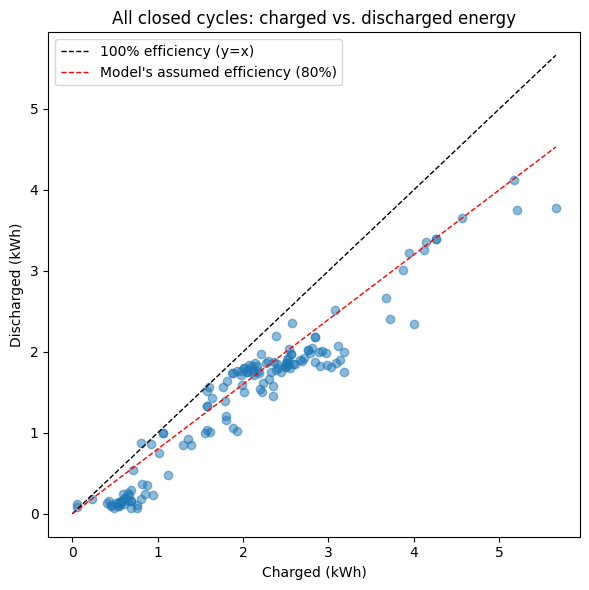

In [26]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(closed_cycles_df['charged_kWh'], closed_cycles_df['discharged_kWh'], alpha=0.5)

max_val = max(closed_cycles_df['charged_kWh'].max(), closed_cycles_df['discharged_kWh'].max())
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='100% efficiency (y=x)')
ax.plot([0, max_val], [0, max_val * 0.80], 'r--', linewidth=1, label="Model's assumed efficiency (80%)")

ax.set_xlabel('Charged (kWh)')
ax.set_ylabel('Discharged (kWh)')
ax.set_title('All closed cycles: charged vs. discharged energy')
ax.legend()
plt.tight_layout()
plt.show()

## Charge Efficiency - maybe too non-linear to use

In [27]:
standby_W_low, standby_W_median, standby_W_high = 5.0, 8.62, 12.0
standby_kW_low = standby_W_low / 1000
standby_kW_median = standby_W_median / 1000
standby_kW_high = standby_W_high / 1000

In [28]:
def find_charge_only_runs(g, load_threshold=0.001, grid_threshold=0.25, min_readings=4,
                           max_gap_hours=0.25, max_readings=20):
    """Find continuous stretches (native 15-min resolution) where ONLY charging
    is happening: load ~ 0, grid > threshold, flex < 0, SoC rising.

    min_readings=5 requires at least 5 consecutive clean 15-min readings
    (~1.25 hours) before a stretch counts as a real run -- a full charge could be as little as ~1.5 hours.

    soc_pct is a start-of-interval snapshot; grid_kWh/load_kWh sum flow DURING
    the interval. So the closing SoC reading for a run ending at row j is read
    from row (j+1) -- the snapshot taken AFTER row j's charging has occurred --
    same alignment fix as the round-trip cycle logic."""
    g = g.sort_values('timestamp').reset_index(drop=True)
    n = len(g)
    runs = []
    i = 0

    def breaks_run(row):
        return (row['load_kWh'] > load_threshold) or (row['grid_kWh'] < grid_threshold) or (row['flex_kWh'] > 0)

        #full_native_df[(full_native_df['flex_kWh']<0) & (full_native_df['grid_kWh']>0) & (full_native_df['load_kWh']<=0)]

    while i < n - 1:
        if breaks_run(g.loc[i]):
            i += 1
            continue

        j = i
        while j < n - 1:
            gap_hours = (g.loc[j + 1, 'timestamp'] - g.loc[j, 'timestamp']).total_seconds() / 3600
            if gap_hours > max_gap_hours:
                break
            if breaks_run(g.loc[j + 1]):
                break
            j += 1

        if j + 1 >= n:
            i = j + 1
            continue

        n_readings = j - i + 1
        if (n_readings >= min_readings) and (n_readings <= max_readings):
            duration_hours = (g.loc[j + 1, 'timestamp'] - g.loc[i, 'timestamp']).total_seconds() / 3600
            segment = g.loc[i:j]
            #grid_charged_kWh = segment['grid_kWh'].sum()
            grid_charged_kWh = segment['flex_kWh'].abs().sum() #flex is negative when charging

            soc_start = g.loc[i, 'soc_pct']
            soc_end = g.loc[j + 1, 'soc_pct']

            if soc_end <= soc_start:
                i = j + 1
                continue

            stored_gained_kWh = (soc_end - soc_start) / 100 * nameplate_Wh / 1000
            standby_loss_low = duration_hours * standby_kW_low
            standby_loss_median = duration_hours * standby_kW_median
            standby_loss_high = duration_hours * standby_kW_high

            if grid_charged_kWh > grid_threshold:
                runs.append({
                    'start_time': g.loc[i, 'timestamp'],
                    'end_time': g.loc[j + 1, 'timestamp'],
                    'duration_hours': duration_hours,
                    'n_readings': n_readings,
                    'soc_start': soc_start,
                    'soc_end': soc_end,
                    'grid_charged_kWh': grid_charged_kWh,
                    'stored_gained_kWh': stored_gained_kWh,
                    'charge_efficiency_raw': stored_gained_kWh / grid_charged_kWh,
                    'charge_efficiency_low': (stored_gained_kWh + standby_loss_low) / grid_charged_kWh,
                    'charge_efficiency_median': (stored_gained_kWh + standby_loss_median) / grid_charged_kWh,
                    'charge_efficiency_high': (stored_gained_kWh + standby_loss_high) / grid_charged_kWh,
                })

        i = j + 1

    return pd.DataFrame(runs)

charge_run_records = []
for (cust, bid), g in full_native_df.groupby(['customer', 'battery_id']):
    r = find_charge_only_runs(g)
    if len(r):
        r['customer'] = cust
        r['battery_id'] = bid
        charge_run_records.append(r)

charge_runs_df = pd.concat(charge_run_records, ignore_index=True)

charge_runs_df['implausible'] = charge_runs_df['charge_efficiency_low'] > 1.0
n_implausible = charge_runs_df['implausible'].sum()
print(f"{n_implausible} of {len(charge_runs_df)} runs implausible (>1.0) even under the most forgiving assumption")

valid_charge_runs_df = charge_runs_df[~charge_runs_df['implausible']]

print(f"\n{len(valid_charge_runs_df)} valid clean charge-only runs across "
      f"{valid_charge_runs_df[['customer','battery_id']].drop_duplicates().shape[0]} batteries")

print("\ncharge_efficiency_raw (no standby adjustment):")
print(valid_charge_runs_df['charge_efficiency_raw'].describe())
print("\ncharge_efficiency_low (standby=5W):")
print(valid_charge_runs_df['charge_efficiency_low'].describe())
print(f"\ncharge_efficiency_median (standby={standby_W_median}W):")
print(valid_charge_runs_df['charge_efficiency_median'].describe())
print("\ncharge_efficiency_high (standby=12W):")
print(valid_charge_runs_df['charge_efficiency_high'].describe())

charge_eff_summary = (valid_charge_runs_df
    .groupby(['customer', 'battery_id'])
    .agg(n_runs=('charge_efficiency_median', 'size'),
         median_charge_efficiency_low=('charge_efficiency_low', 'median'),
         median_charge_efficiency_median=('charge_efficiency_median', 'median'),
         median_charge_efficiency_high=('charge_efficiency_high', 'median'),
         avg_duration_hours=('duration_hours', 'mean'))
)
charge_eff_summary

0 of 21 runs implausible (>1.0) even under the most forgiving assumption

21 valid clean charge-only runs across 16 batteries

charge_efficiency_raw (no standby adjustment):
count    21.000000
mean      0.788274
std       0.043481
min       0.674663
25%       0.766973
50%       0.792471
75%       0.813968
max       0.862115
Name: charge_efficiency_raw, dtype: float64

charge_efficiency_low (standby=5W):
count    21.000000
mean      0.791957
std       0.043507
min       0.678252
25%       0.770519
50%       0.796150
75%       0.817522
max       0.865694
Name: charge_efficiency_low, dtype: float64

charge_efficiency_median (standby=8.62W):
count    21.000000
mean      0.794623
std       0.043526
min       0.680851
25%       0.773086
50%       0.798814
75%       0.820095
max       0.868286
Name: charge_efficiency_median, dtype: float64

charge_efficiency_high (standby=12W):
count    21.000000
mean      0.797113
std       0.043546
min       0.683277
25%       0.775482
50%       0.801301
75

,,n_runs,median_charge_efficiency_low,median_charge_efficiency_median,median_charge_efficiency_high,avg_duration_hours
customer,battery_id,,,,,
7,1,1,0.785410,0.787752,0.789939,1.50
16,2,2,0.801636,0.804189,0.806574,1.25
17,1,2,0.803783,0.806334,0.808715,1.25
22,1,1,0.809845,0.812531,0.815039,1.00
25,1,1,0.797636,0.800571,0.803311,2.00
28,1,2,0.721941,0.724645,0.727171,1.00
31,1,1,0.789167,0.792295,0.795216,1.75
35,1,2,0.806862,0.809505,0.811972,1.25
39,2,1,0.810349,0.813512,0.816465,2.00


In [29]:
charge_eff_summary.describe()

,n_runs,median_charge_efficiency_low,median_charge_efficiency_median,median_charge_efficiency_high,avg_duration_hours
count,16.000000,16.000000,16.000000,16.000000,16.000000
mean,1.312500,0.791622,0.794304,0.796809,1.359375
std,0.478714,0.037144,0.037168,0.037191,0.341184
min,1.000000,0.721941,0.724645,0.727171,1.000000
25%,1.000000,0.777533,0.779919,0.782147,1.000000
50%,1.000000,0.802709,0.805262,0.807644,1.250000
75%,2.000000,0.809971,0.812776,0.815396,1.500000
max,2.000000,0.839989,0.842539,0.845070,2.000000


In [30]:
# ---- Identify outlier charge runs ----

# Group 1: already flagged as physically implausible (>1.0 even under standby=5W, the most forgiving case)
implausible_outliers = charge_runs_df[charge_runs_df['implausible']].sort_values(
    'charge_efficiency_low', ascending=False
)

# Group 2: statistical outliers within the physically plausible runs (IQR on charge_efficiency_median)
q1 = valid_charge_runs_df['charge_efficiency_median'].quantile(0.25)
q3 = valid_charge_runs_df['charge_efficiency_median'].quantile(0.75)
iqr = q3 - q1
low_bound = q1 - 1.5 * iqr
high_bound = q3 + 1.5 * iqr

stat_outliers = valid_charge_runs_df[
    (valid_charge_runs_df['charge_efficiency_median'] < low_bound) |
    (valid_charge_runs_df['charge_efficiency_median'] > high_bound)
].sort_values('charge_efficiency_median')

print(f"{len(implausible_outliers)} implausible runs (charge_efficiency_low > 1.0)")
print(f"{len(stat_outliers)} statistical outliers among valid runs "
      f"(outside [{low_bound:.2f}, {high_bound:.2f}])")

cols = ['customer', 'battery_id', 'start_time', 'end_time', 'duration_hours', 'n_readings',
        'grid_charged_kWh', 'stored_gained_kWh',
        'charge_efficiency_raw', 'charge_efficiency_low', 'charge_efficiency_median',
        'charge_efficiency_high', 'implausible']

print("\n--- Implausible runs ---")
display(implausible_outliers[cols])

print("\n--- Statistical outliers (valid runs) ---")
display(stat_outliers[cols])

0 implausible runs (charge_efficiency_low > 1.0)
1 statistical outliers among valid runs (outside [0.70, 0.89])

--- Implausible runs ---


,customer,battery_id,start_time,end_time,duration_hours,n_readings,grid_charged_kWh,stored_gained_kWh,charge_efficiency_raw,charge_efficiency_low,charge_efficiency_median,charge_efficiency_high,implausible



--- Statistical outliers (valid runs) ---


,customer,battery_id,start_time,end_time,duration_hours,n_readings,grid_charged_kWh,stored_gained_kWh,charge_efficiency_raw,charge_efficiency_low,charge_efficiency_median,charge_efficiency_high,implausible
7,28,1,2025-06-24 16:30:00-04:00,2025-06-24 17:30:00-04:00,1.0,4,1.392933,0.93976,0.674663,0.678252,0.680851,0.683277,False


In [31]:
# ---- Compare each outlier to non-outlier runs of similar duration ----

outliers_df = pd.concat([implausible_outliers, stat_outliers]).drop_duplicates()

# runs that are NOT outliers, to serve as the comparison pool
non_outlier_runs = valid_charge_runs_df.drop(
    index=stat_outliers.index, errors='ignore'
)

duration_tolerance_hours = 0.5  # how close a "similar duration" match needs to be

energy_cols = ['duration_hours', 'n_readings', 'grid_charged_kWh', 'stored_gained_kWh',
               'charge_efficiency_raw', 'charge_efficiency_low',
               'charge_efficiency_median', 'charge_efficiency_high']

comparison_rows = []

for idx, outlier in outliers_df.iterrows():
    dur = outlier['duration_hours']

    matched = non_outlier_runs[
        (non_outlier_runs['duration_hours'] >= dur - duration_tolerance_hours) &
        (non_outlier_runs['duration_hours'] <= dur + duration_tolerance_hours)
    ]

    print(f"\n=== Outlier: customer {outlier['customer']}, battery {outlier['battery_id']}, "
          f"{outlier['start_time']} (duration={dur:.2f}h) ===")
    print(f"Matched {len(matched)} non-outlier runs within ±{duration_tolerance_hours}h")

    if len(matched) == 0:
        print("No matches at this tolerance -- widen duration_tolerance_hours")
        continue

    # side-by-side: outlier's own values vs matched-group median/mean
    row = {'label': 'outlier'}
    row.update({c: outlier[c] for c in energy_cols})
    comparison_rows.append(row)

    row = {'label': 'matched_median'}
    row.update({c: matched[c].median() for c in energy_cols})
    comparison_rows.append(row)

    row = {'label': 'matched_mean'}
    row.update({c: matched[c].mean() for c in energy_cols})
    comparison_rows.append(row)

    row = {'label': 'matched_std'}
    row.update({c: matched[c].std() for c in energy_cols})
    comparison_rows.append(row)

    comparison_df = pd.DataFrame(comparison_rows[-4:]).set_index('label')
    display(comparison_df)

    comparison_rows = []  # reset for next outlier's own table


=== Outlier: customer 28, battery 1, 2025-06-24 16:30:00-04:00 (duration=1.00h) ===
Matched 17 non-outlier runs within ±0.5h


,duration_hours,n_readings,grid_charged_kWh,stored_gained_kWh,charge_efficiency_raw,charge_efficiency_low,charge_efficiency_median,charge_efficiency_high
label,,,,,,,,
outlier,1.00,4.0,1.392933,0.939760,0.674663,0.678252,0.680851,0.683277
matched_median,1.25,5.0,1.774450,1.484268,0.792471,0.796150,0.798814,0.801301
matched_mean,1.25,5.0,1.747874,1.389154,0.793804,0.797393,0.799992,0.802418
matched_std,0.25,1.0,0.374910,0.310743,0.038755,0.038768,0.038777,0.038787


## Discharge Efficiency

In [32]:
def find_discharge_only_runs(g, load_threshold=0.02, grid_threshold=0.005, min_readings=10,
                              max_gap_hours=0.5):
    """Find continuous stretches (native 15-min resolution) where ONLY discharging
    is happening: grid ~ 0 (nothing coming from the grid), load > threshold
    (battery is actively serving load), SoC falling. Mirror of
    find_charge_only_runs.

    discharge_efficiency = AC energy served to load / stored energy actually
    drawn from the battery. Stored energy drawn = SoC-implied drop MINUS
    standby loss during the same window, since standby also draws from
    storage but never reaches the load meter -- so subtracting it (not adding,
    as we do for charge efficiency) isolates the energy that went through the
    inverter to serve load.

    soc_pct is a start-of-interval snapshot; load_kWh sums flow DURING the
    interval, so soc_end for a run ending at row j is read from row (j+1),
    same alignment fix as the other functions."""
    g = g.sort_values('timestamp').reset_index(drop=True)
    n = len(g)
    runs = []
    i = 0

    def breaks_run(row):
        return (row['grid_kWh'] > grid_threshold) or (row['load_kWh'] <= load_threshold)

    while i < n - 1:
        if breaks_run(g.loc[i]):
            i += 1
            continue

        j = i
        while j < n - 1:
            gap_hours = (g.loc[j + 1, 'timestamp'] - g.loc[j, 'timestamp']).total_seconds() / 3600
            if gap_hours > max_gap_hours:
                break
            if breaks_run(g.loc[j + 1]):
                break
            j += 1

        if j + 1 >= n:
            i = j + 1
            continue

        n_readings = j - i + 1
        if n_readings >= min_readings:
            duration_hours = (g.loc[j + 1, 'timestamp'] - g.loc[i, 'timestamp']).total_seconds() / 3600
            segment = g.loc[i:j]
            ac_discharged_kWh = segment['load_kWh'].sum()

            soc_start = g.loc[i, 'soc_pct']
            soc_end = g.loc[j + 1, 'soc_pct']

            # require SoC to have actually fallen -- confirms real discharge,
            # not just a quiet stretch where load barely cleared the threshold
            if soc_end >= soc_start:
                i = j + 1
                continue

            stored_drawn_kWh = (soc_start - soc_end) / 100 * nameplate_Wh / 1000
            standby_loss_low = duration_hours * standby_kW_low
            standby_loss_median = duration_hours * standby_kW_median
            standby_loss_high = duration_hours * standby_kW_high

            # subtract standby -- some of the SoC drop is standby draw, not
            # energy that reached the load via the inverter. Use max(..., small
            # floor) to avoid dividing by ~zero or negative if standby loss is
            # large relative to a thin stretch.
            stored_via_inverter_low = max(stored_drawn_kWh - standby_loss_low, 0.01)
            stored_via_inverter_median = max(stored_drawn_kWh - standby_loss_median, 0.01)
            stored_via_inverter_high = max(stored_drawn_kWh - standby_loss_high, 0.01)

            if ac_discharged_kWh > 0.05:
                runs.append({
                    'start_time': g.loc[i, 'timestamp'],
                    'end_time': g.loc[j + 1, 'timestamp'],
                    'duration_hours': duration_hours,
                    'n_readings': n_readings,
                    'soc_start': soc_start,
                    'soc_end': soc_end,
                    'ac_discharged_kWh': ac_discharged_kWh,
                    'stored_drawn_kWh': stored_drawn_kWh,
                    'discharge_efficiency_raw': ac_discharged_kWh / stored_drawn_kWh,
                    'discharge_efficiency_low': ac_discharged_kWh / stored_via_inverter_low,
                    'discharge_efficiency_median': ac_discharged_kWh / stored_via_inverter_median,
                    'discharge_efficiency_high': ac_discharged_kWh / stored_via_inverter_high,
                })

        i = j + 1

    return pd.DataFrame(runs)


discharge_run_records = []
for (cust, bid), g in full_native_df.groupby(['customer', 'battery_id']):
    r = find_discharge_only_runs(g)
    if len(r):
        r['customer'] = cust
        r['battery_id'] = bid
        discharge_run_records.append(r)

discharge_runs_df = pd.concat(discharge_run_records, ignore_index=True)

discharge_runs_df['implausible'] = discharge_runs_df['discharge_efficiency_high'] > 1.0
n_implausible = discharge_runs_df['implausible'].sum()
print(f"{n_implausible} of {len(discharge_runs_df)} runs implausible (>1.0) even under the most forgiving assumption")

valid_discharge_runs_df = discharge_runs_df[~discharge_runs_df['implausible']]

print(f"\n{len(valid_discharge_runs_df)} valid clean discharge-only runs across "
      f"{valid_discharge_runs_df[['customer','battery_id']].drop_duplicates().shape[0]} batteries")

print("\ndischarge_efficiency_raw (no standby adjustment):")
print(valid_discharge_runs_df['discharge_efficiency_raw'].describe())
print("\ndischarge_efficiency_low (standby=12W):")
print(valid_discharge_runs_df['discharge_efficiency_low'].describe())
print(f"\ndischarge_efficiency_median (standby={standby_W_median}W):")
print(valid_discharge_runs_df['discharge_efficiency_median'].describe())
print("\ndischarge_efficiency_high (standby=5W):")
print(valid_discharge_runs_df['discharge_efficiency_high'].describe())

discharge_eff_summary = (valid_discharge_runs_df
    .groupby(['customer', 'battery_id'])
    .agg(n_runs=('discharge_efficiency_median', 'size'),
         median_discharge_efficiency_low=('discharge_efficiency_low', 'median'),
         median_discharge_efficiency_median=('discharge_efficiency_median', 'median'),
         median_discharge_efficiency_high=('discharge_efficiency_high', 'median'),
         avg_duration_hours=('duration_hours', 'mean'))
)
discharge_eff_summary

30 of 69 runs implausible (>1.0) even under the most forgiving assumption

39 valid clean discharge-only runs across 29 batteries

discharge_efficiency_raw (no standby adjustment):
count    39.000000
mean      0.943890
std       0.026074
min       0.889037
25%       0.929036
50%       0.946560
75%       0.964904
max       0.978597
Name: discharge_efficiency_raw, dtype: float64

discharge_efficiency_low (standby=12W):
count    39.000000
mean      0.954290
std       0.025086
min       0.897872
25%       0.938086
50%       0.957148
75%       0.975269
max       0.986519
Name: discharge_efficiency_low, dtype: float64

discharge_efficiency_median (standby=8.62W):
count    39.000000
mean      0.961981
std       0.024622
min       0.904379
25%       0.944750
50%       0.967627
75%       0.983192
max       0.992335
Name: discharge_efficiency_median, dtype: float64

discharge_efficiency_high (standby=5W):
count    39.000000
mean      0.969289
std       0.024428
min       0.910541
25%       0.951

n_runs  median_discharge_efficiency_low  \
customer battery_id                                            
1        1                1                         0.913020   
3        1                2                         0.978592   
         2                1                         0.985447   
5        1                1                         0.954138   
10       1                1                         0.913020   
13       1                2                         0.958960   
16       1                2                         0.926705   
19       1                1                         0.920396   
27       1                3                         0.949917   
29       1                1                         0.961356   
30       1                2                         0.978592   
         2                1                         0.985447   
32       1                1                         0.945867   
35       1                1                         0.940417   
36       1                1                         0.924299   
41       1                1                         0.897872   
42       1                2                         0.980937   
43       1                1                         0.955373   
         2                3                         0.964221   
44       1                1                         0.957148   
46       1                1                         0.979622   
48       1                1                         0.953493   
49       2                1                         0.986519   
         3                1                         0.920837   
50       1                1                         0.954138   
51       1                2                         0.975269   
53       1                1                         0.949797   
55       1                1                         0.960084   
58       3                1                         0.969169   

                     median_discharge_efficiency_median  \
customer battery_id                                       
1        1                                     0.928895   
3        1                                     0.985487   
         2                                     0.991737   
5        1                                     0.960955   
10       1                                     0.928895   
13       1                                     0.966953   
16       1                                     0.931627   
19       1                                     0.926120   
27       1                                     0.956827   
29       1                                     0.968714   
30       1                                     0.985487   
         2                                     0.991737   
32       1                                     0.955631   
35       1                                     0.947226   
36       1                                     0.931936   
41       1                                     0.904379   
42       1                                     0.988405   
43       1                                     0.963594   
         2                                     0.970422   
44       1                                     0.969552   
46       1                                     0.987505   
48       1                                     0.958575   
49       2                                     0.992335   
         3                                     0.926385   
50       1                                     0.960955   
51       1                                     0.982914   
53       1                                     0.956438   
55       1                                     0.967952   
58       3                                     0.982724   

                     median_discharge_efficiency_high  avg_duration_hours  
customer battery_id                                                        
1        1                                   0.944224 

In [33]:
# def find_discharge_only_runs(g, grid_threshold=0.02, flex_threshold=0.02, min_readings=5,
#                               max_gap_hours=0.5):
#     """Find continuous stretches (native 15-min resolution) where ONLY discharging
#     is happening: grid ~ 0 (nothing from the grid), flex_kWh > threshold (battery
#     is actively discharging, per the RAW metered discharge column), SoC falling.

#     flex_kWh is the direct battery_discharge_kwh column from the source data,
#     not something derived from load - grid -- using it directly is more
#     reliable than inferring discharge from load_kWh."""
#     g = g.sort_values('timestamp').reset_index(drop=True)
#     n = len(g)
#     runs = []
#     i = 0

#     def breaks_run(row):
#         return (row['grid_kWh'] > grid_threshold) or (row['flex_kWh'] <= flex_threshold)

#     while i < n - 1:
#         if breaks_run(g.loc[i]):
#             i += 1
#             continue

#         j = i
#         while j < n - 1:
#             gap_hours = (g.loc[j + 1, 'timestamp'] - g.loc[j, 'timestamp']).total_seconds() / 3600
#             if gap_hours > max_gap_hours:
#                 break
#             if breaks_run(g.loc[j + 1]):
#                 break
#             j += 1

#         if j + 1 >= n:
#             i = j + 1
#             continue

#         n_readings = j - i + 1
#         if n_readings >= min_readings:
#             duration_hours = (g.loc[j + 1, 'timestamp'] - g.loc[i, 'timestamp']).total_seconds() / 3600
#             segment = g.loc[i:j]
#             ac_discharged_kWh = segment['flex_kWh'].sum()  # direct metered discharge, not load

#             soc_start = g.loc[i, 'soc_pct']
#             soc_end = g.loc[j + 1, 'soc_pct']

#             if soc_end >= soc_start:
#                 i = j + 1
#                 continue

#             stored_drawn_kWh = (soc_start - soc_end) / 100 * nameplate_Wh / 1000
#             standby_loss_low = duration_hours * standby_kW_low
#             standby_loss_median = duration_hours * standby_kW_median
#             standby_loss_high = duration_hours * standby_kW_high

#             stored_via_inverter_low = max(stored_drawn_kWh - standby_loss_low, 0.01)
#             stored_via_inverter_median = max(stored_drawn_kWh - standby_loss_median, 0.01)
#             stored_via_inverter_high = max(stored_drawn_kWh - standby_loss_high, 0.01)

#             if ac_discharged_kWh > 0.1:
#                 runs.append({
#                     'start_time': g.loc[i, 'timestamp'],
#                     'end_time': g.loc[j + 1, 'timestamp'],
#                     'duration_hours': duration_hours,
#                     'n_readings': n_readings,
#                     'soc_start': soc_start,
#                     'soc_end': soc_end,
#                     'ac_discharged_kWh': ac_discharged_kWh,
#                     'stored_drawn_kWh': stored_drawn_kWh,
#                     'discharge_efficiency_raw': ac_discharged_kWh / stored_drawn_kWh,
#                     'discharge_efficiency_low': ac_discharged_kWh / stored_via_inverter_low,
#                     'discharge_efficiency_median': ac_discharged_kWh / stored_via_inverter_median,
#                     'discharge_efficiency_high': ac_discharged_kWh / stored_via_inverter_high,
#                 })

#         i = j + 1

#     return pd.DataFrame(runs)


# discharge_run_records = []
# for (cust, bid), g in full_native_df.groupby(['customer', 'battery_id']):
#     r = find_discharge_only_runs(g)
#     if len(r):
#         r['customer'] = cust
#         r['battery_id'] = bid
#         discharge_run_records.append(r)

# discharge_runs_df = pd.concat(discharge_run_records, ignore_index=True)
# discharge_runs_df['implausible'] = discharge_runs_df['discharge_efficiency_high'] > 1.0
# valid_discharge_runs_df = discharge_runs_df[~discharge_runs_df['implausible']]

# print(f"{len(valid_discharge_runs_df)} valid clean discharge-only runs")
# print(valid_discharge_runs_df['discharge_efficiency_median'].describe())

In [34]:
discharge_eff_summary.describe()

,n_runs,median_discharge_efficiency_low,median_discharge_efficiency_median,median_discharge_efficiency_high,avg_duration_hours
count,29.000000,29.000000,29.000000,29.000000,29.000000
mean,1.344828,0.953126,0.961047,0.968580,3.741379
std,0.613879,0.024763,0.024231,0.024027,0.990304
min,1.000000,0.897872,0.904379,0.910541,2.500000
25%,1.000000,0.940417,0.947226,0.953674,3.083333
50%,1.000000,0.955373,0.963594,0.971398,3.500000
75%,2.000000,0.975269,0.982914,0.992015,4.125000
max,3.000000,0.986519,0.992335,0.997828,7.250000


### Household variability

In [35]:
reliability_summary = (hourly_validation_df
    .groupby(['customer', 'battery_id', 'event'])['observed_flex_kW']
    .sum()
    .groupby(['customer', 'battery_id'])
    .agg(mean_event_flex_kWh='mean', std_event_flex_kWh='std', n_events='count')
)
reliability_summary['cv'] = reliability_summary['std_event_flex_kWh'] / reliability_summary['mean_event_flex_kWh']
reliability_summary.sort_values('cv', ascending=False)

,,mean_event_flex_kWh,std_event_flex_kWh,n_events,cv
customer,battery_id,,,,
54,1,0.334872,0.580016,3,1.732051
6,1,0.163433,0.283075,3,1.732051
39,2,0.187394,0.324577,3,1.732051
60,1,0.163433,0.283075,3,1.732051
18,1,0.006761,0.011711,3,1.732051
...,...,...,...,...,...
36,2,0.000000,0.000000,3,NaN
40,1,0.000000,0.000000,3,NaN
49,1,0.000000,0.000000,3,NaN


# Day to day consumption variability

In [110]:
# returns the average load for each event
load_by_event = (
    hourly_validation_df[~hourly_validation_df['customer'].isin([20, 35])]
    .groupby(['customer', 'battery_id', 'event'])
    .agg(first_timestamp=('timestamp', 'first'),
         mean_load_kW=('observed_load_kW', 'mean'))
    .reset_index()
)
load_by_event.head(10)

,customer,battery_id,event,first_timestamp,mean_load_kW
0,1,1,1,2025-06-23 16:00:00-04:00,0.212008
1,1,1,2,2025-06-24 16:00:00-04:00,0.169167
2,1,1,3,2025-06-25 16:00:00-04:00,0.193342
3,3,1,1,2025-06-23 16:00:00-04:00,0.437883
4,3,1,2,2025-06-24 16:00:00-04:00,0.426217
5,3,1,3,2025-06-25 16:00:00-04:00,0.551625
6,3,2,1,2025-06-23 16:00:00-04:00,0.885025
7,3,2,2,2025-06-24 16:00:00-04:00,0.579546
8,3,2,3,2025-06-25 16:00:00-04:00,0.520483
9,4,1,1,2025-06-23 16:00:00-04:00,0.000000


In [111]:
# returns the standard deviation and CV of the load during events by customer/battery
load_variability_by_event = (
    load_by_event
    .groupby(['customer', 'battery_id'])
    .agg(first_timestamp=('first_timestamp', 'first'),
         mean_load_kW=('mean_load_kW', 'mean'),
         std_load_kW=('mean_load_kW', 'std'),
         n_events=('mean_load_kW', 'count'))
)

load_variability_by_event['cv'] = np.where(
    (load_variability_by_event['mean_load_kW'] == 0) & (load_variability_by_event['std_load_kW'] == 0),
    0,
    load_variability_by_event['std_load_kW'] / load_variability_by_event['mean_load_kW']
)

In [112]:
load_variability_by_event

first_timestamp  mean_load_kW  std_load_kW  \
customer battery_id                                                        
1        1          2025-06-23 16:00:00-04:00      0.191506     0.021480   
3        1          2025-06-23 16:00:00-04:00      0.471908     0.069283   
         2          2025-06-23 16:00:00-04:00      0.661685     0.195660   
4        1          2025-06-23 16:00:00-04:00      0.000000     0.000000   
5        1          2025-06-23 11:00:00-04:00      0.273606     0.056836   
...                                       ...           ...          ...   
58       2          2025-06-23 16:00:00-04:00      0.889251     0.126124   
         3          2025-06-23 16:00:00-04:00      0.218300     0.053712   
59       1          2025-06-23 16:00:00-04:00      0.581404     0.158892   
         2          2025-06-23 16:00:00-04:00      0.147567     0.255593   
60       1          2025-06-23 16:00:00-04:00      0.040858     0.070769   

                     n_events        cv  
customer battery_id                      
1        1                  3  0.112163  
3        1                  3  0.146814  
         2                  3  0.295699  
4        1                  3  0.000000  
5        1                  3  0.207728  
...                       ...       ...  
58       2                  3  0.141832  
         3                  3  0.246046  
59       1                  3  0.273290  
         2                  3  1.732051  
60       1                  3  1.732051  

[74 rows x 5 columns]

In [118]:
load_variability_by_event.describe()

,mean_load_kW,std_load_kW,n_events,cv
count,74.000000,74.000000,74.0,74.000000
mean,0.396603,0.139441,3.0,0.497341
std,0.336577,0.143472,0.0,0.564417
min,0.000000,0.000000,3.0,0.000000
25%,0.109808,0.029376,3.0,0.084255
50%,0.319801,0.093722,3.0,0.262601
75%,0.605307,0.195660,3.0,0.710430
max,1.308447,0.553665,3.0,1.732051


In [126]:
load_variability_by_event_noZ = load_variability_by_event[load_variability_by_event['cv']>0.0]
print(load_variability_by_event_noZ[load_variability_by_event_noZ['first_timestamp'].dt.hour == 19]['cv'].mean())
print(load_variability_by_event_noZ[load_variability_by_event_noZ['first_timestamp'].dt.hour == 19]['cv'].median())

0.6448616516115648
0.6448616516115648


In [113]:
load_variability_by_event[load_variability_by_event['first_timestamp'].dt.hour == 11].describe()

,mean_load_kW,std_load_kW,n_events,cv
count,3.000000,3.000000,3.0,3.000000
mean,0.606367,0.049727,3.0,0.147791
std,0.576360,0.012313,0.0,0.103813
min,0.273606,0.035509,3.0,0.027918
25%,0.273606,0.046172,3.0,0.117823
50%,0.273606,0.056836,3.0,0.207728
75%,0.772748,0.056836,3.0,0.207728
max,1.271890,0.056836,3.0,0.207728


In [114]:
load_variability_by_event[load_variability_by_event['first_timestamp'].dt.hour == 14].describe()

,mean_load_kW,std_load_kW,n_events,cv
count,22.000000,22.000000,22.0,22.000000
mean,0.488812,0.172291,3.0,0.444970
std,0.349501,0.163935,0.0,0.489874
min,0.000000,0.000000,3.0,0.000000
25%,0.242328,0.056236,3.0,0.091807
50%,0.454412,0.137514,3.0,0.285058
75%,0.773757,0.223293,3.0,0.600937
max,1.063936,0.553665,3.0,1.732051


In [115]:
load_variability_by_event[load_variability_by_event['first_timestamp'].dt.hour == 16].describe()

,mean_load_kW,std_load_kW,n_events,cv
count,45.000000,45.000000,45.0,45.000000
mean,0.360331,0.133721,3.0,0.576126
std,0.307596,0.133224,0.0,0.616521
min,0.000000,0.000000,3.0,0.000000
25%,0.126179,0.032482,3.0,0.123274
50%,0.277594,0.090810,3.0,0.295699
75%,0.552924,0.195660,3.0,0.874173
max,1.308447,0.532520,3.0,1.732051


In [116]:
load_variability_by_event[load_variability_by_event['first_timestamp'].dt.hour == 19].describe()

,mean_load_kW,std_load_kW,n_events,cv
count,4.000000,4.000000,4.0,4.000000
mean,0.140187,0.090401,3.0,0.161215
std,0.280374,0.180802,0.0,0.322431
min,0.000000,0.000000,3.0,0.000000
25%,0.000000,0.000000,3.0,0.000000
50%,0.000000,0.000000,3.0,0.000000
75%,0.140187,0.090401,3.0,0.161215
max,0.560748,0.361605,3.0,0.644862
